# Lung Cancer Classification with AI — Your First Deep Learning Notebook

Welcome! In this notebook you will train a real deep-learning model that looks at chest CT images and learns to tell **normal** tissue apart from **lung cancer**. The dataset was built specifically for this course from [The Cancer Imaging Archive (TCIA)](https://www.cancerimagingarchive.net/): for each patient, the CT slice showing the tumor was split down the middle into a diseased half and a healthy half — both from the exact same scan, so there's no hidden shortcut for the model to exploit. You will build the model yourself, train it, and see how well it performs using a **ROC curve** — the same kind of curve used to report sensitivity/specificity trade-offs in the clinic.

**What you'll do, step by step:**
1. Download the CT image dataset
2. Look at the images you downloaded, and count how many you have per class
3. Build your own train / validation / test split (proportions and randomness under your control)
4. Prepare the images for the model
5. Build and train your own classifier (you choose the settings, including CPU vs GPU!)
6. Look at the ROC curve, the AUC, and how long training took

You don't need to know how to code to follow along — just run each cell in order and read the notes above it.

## Before you start — a quick checklist

- **Google account**: Colab needs a Google account to run code. Check the top-right corner of this page — if you're not signed in, sign in now (or create a free account at [accounts.google.com/signup](https://accounts.google.com/signup) before the session).
- **Your own copy**: if you opened this notebook from a shared link, you already have your own working copy — nothing you do here affects your classmates. If you'd like to keep this notebook after today, use **File → Save a copy in Drive**.
- **Turn on the GPU** (recommended — training is much faster): go to **Runtime → Change runtime type → Hardware accelerator → GPU**, then click Save. Don't worry if you forget — in Step 3 you'll get a dropdown to pick CPU or GPU, and we'll measure and compare how long each one takes.
- **Running cells**: click the ▶ button on the left of a cell, or select it and press **Shift+Enter**. Run the cells **in order, top to bottom** — later cells depend on earlier ones.
- **If something breaks**: don't panic. Go to **Runtime → Restart session**, then run all cells again from the top (**Runtime → Run all**).

## Step 1: Get the data

Now we will download the dataset your instructor prepared from Google Drive, and unzip it. It contains chest CT images in two folders, **Cancer** and **Normal** — each pair sharing a filename comes from the same patient's scan (see Step 2 for what that means).

Just run the cell below and wait for it to finish — you'll see download progress messages. There is nothing to change here.

In [1]:
#@title Download the dataset
!pip install -q gdown
import gdown, zipfile, os

FILE_ID = "1JXcOQZuhcWTzP3WhtYXmEMUm-QOha2hH"
zip_path = "/content/tcia_lung_dataset.zip"
DATA_ROOT = "/content/tcia_lung_dataset"

gdown.download(id=FILE_ID, output=zip_path, quiet=False)

with zipfile.ZipFile(zip_path, "r") as z:
    z.extractall(DATA_ROOT)

print("Extracted to:", DATA_ROOT)
print("Folders found:", os.listdir(DATA_ROOT))

Downloading...
From: https://drive.google.com/uc?id=1JXcOQZuhcWTzP3WhtYXmEMUm-QOha2hH
To: /content/tcia_lung_dataset.zip
100%|██████████| 17.9M/17.9M [00:00<00:00, 148MB/s]


Extracted to: /content/tcia_lung_dataset
Folders found: ['Normal', 'Cancer']


This next cell simply tells Python **where** to find the two class folders we just downloaded, and counts how many images are in each. Nothing to edit — just run it.

In [2]:
cancer_dir = os.path.join(DATA_ROOT, "Cancer")
normal_dir = os.path.join(DATA_ROOT, "Normal")

print("Cancer images:", len(os.listdir(cancer_dir)))
print("Normal images:", len(os.listdir(normal_dir)))

Cancer images: 250
Normal images: 250


## Step 2: Look at your data

Before writing any deep-learning code, let's actually **look** at some of the images we just downloaded. This is good practice any time you start a new project — always check your data before trusting any model built on it.

Use the dropdowns below to pick a class (or a mix of both) and how many images to show. Try comparing a Cancer image with the Normal image that shares its filename — same patient, same scan, opposite halves.

In [3]:
#@title 🔍 Preview: what does the dataset look like?
import os, random
import matplotlib.pyplot as plt
from PIL import Image
import ipywidgets as W
from IPython.display import display, clear_output

try:
    from google.colab import output as _co; _co.enable_custom_widget_manager()
except Exception:
    pass

cancer_files = sorted(os.listdir(cancer_dir))
normal_files = sorted(os.listdir(normal_dir))
print("Images found:")
print("  %-10s: %d" % ("Cancer", len(cancer_files)))
print("  %-10s: %d" % ("Normal", len(normal_files)))
print("\nEach filename is a random case ID that appears in BOTH folders - the Cancer and")
print("Normal image sharing that ID come from the SAME patient's CT scan, split down the")
print("middle: the half containing the tumor, and the opposite (healthy) half.")

POOL_PREVIEW = {
    "Cancer": [os.path.join(cancer_dir, f) for f in cancer_files],
    "Normal": [os.path.join(normal_dir, f) for f in normal_files],
}

class_dd = W.Dropdown(options=["Cancer", "Normal", "All classes (mixed)"],
                      value="All classes (mixed)", description="show")
n_dd = W.Dropdown(options=[4, 8, 12], value=8, description="images")
out = W.Output()

def render(*_):
    with out:
        clear_output(wait=True)
        if class_dd.value == "All classes (mixed)":
            paths_labels = []
            for name, imgs in POOL_PREVIEW.items():
                for pth in random.sample(imgs, min(n_dd.value // 2, len(imgs))):
                    paths_labels.append((pth, name))
            random.shuffle(paths_labels)
            paths_labels = paths_labels[:n_dd.value]
        else:
            imgs = POOL_PREVIEW[class_dd.value]
            paths_labels = [(pth, class_dd.value) for pth in random.sample(imgs, min(n_dd.value, len(imgs)))]

        n = len(paths_labels)
        cols = 4
        rows = (n + cols - 1) // cols
        fig, axes = plt.subplots(rows, cols, figsize=(3 * cols, 3 * rows))
        axes = axes.flatten() if n > 1 else [axes]
        for ax, (pth, label) in zip(axes, paths_labels):
            ax.imshow(Image.open(pth).convert("RGB"))
            ax.set_title(label, fontsize=9)
            ax.axis("off")
        for ax in axes[len(paths_labels):]:
            ax.axis("off")
        plt.tight_layout()
        plt.show()

for w in (class_dd, n_dd):
    w.observe(render, "value")
display(W.HBox([W.VBox([class_dd, n_dd]), out]))
render()

Images found:
  Cancer    : 250
  Normal    : 250

Each filename is a random case ID that appears in BOTH folders - the Cancer and
Normal image sharing that ID come from the SAME patient's CT scan, split down the
middle: the half containing the tumor, and the opposite (healthy) half.


## Step 3: Build your own train / validation / test split

This dataset is already clean — no duplicates, because each patient contributes exactly one Cancer image and one Normal image, both cropped from the same CT slice. So there's no deduplication to do here (unlike some other datasets, where images can be copied or resaved many times).

There is still one thing **you** must get right: **the Cancer and Normal image from the same patient must always end up in the same split.** If patient X's Cancer half landed in training and their Normal half landed in test, the model could learn to recognize *that specific patient's scan* rather than anything about disease — the same kind of leak we found and fixed earlier in this course, just in a new disguise. The cell below splits by **patient**, not by image, so this can't happen.

The **seed** controls the random shuffle before splitting — keep it fixed (default) if you want a split you can reproduce and compare with classmates; change it to explore how much results vary with a different random split of the same data.

Move the sliders and click **Build split** (a default split is built automatically so you can also just continue if you prefer).

In [4]:
#@title 🔀 Build your own train/val/test split (grouped by patient)
import os, random, shutil
import ipywidgets as W
from IPython.display import display, clear_output

try:
    from google.colab import output as _co; _co.enable_custom_widget_manager()
except Exception:
    pass

cancer_tokens = {os.path.splitext(f)[0] for f in os.listdir(cancer_dir)}
normal_tokens = {os.path.splitext(f)[0] for f in os.listdir(normal_dir)}
assert cancer_tokens == normal_tokens, "Cancer/Normal folders don't have matching pairs - check the download."
TOKENS = sorted(cancer_tokens)
print("Found %d matched patient cases (%d images total)." % (len(TOKENS), 2 * len(TOKENS)))
print("No deduplication needed here - each case contributes exactly one Cancer and one")
print("Normal image, both from the same scan, so there's nothing to deduplicate.")

test_pct_w = W.IntSlider(value=15, min=5, max=40, step=5, description="test %")
val_pct_w  = W.IntSlider(value=15, min=5, max=40, step=5, description="val %")
seed_w     = W.IntText(value=42, description="seed")
info_l     = W.HTML()
build_btn  = W.Button(description="Build split", button_style="success", icon="random")
status     = W.HTML()
out        = W.Output()

def update_info(*_):
    train_pct = 100 - test_pct_w.value - val_pct_w.value
    color = "black" if train_pct >= 20 else "crimson"
    info_l.value = ("train %% = <b style='color:%s'>%d</b>&nbsp;&nbsp;"
                    "(test %d%% + val %d%% + train %d%% = 100%%)"
                    % (color, train_pct, test_pct_w.value, val_pct_w.value, train_pct))
for w in (test_pct_w, val_pct_w):
    w.observe(update_info, "value")
update_info()

SPLIT_ROOT = "/content/my_split"

def on_build(_):
    build_btn.disabled = True
    with out:
        clear_output(wait=True)
        train_pct = 100 - test_pct_w.value - val_pct_w.value
        if train_pct < 20:
            print("⚠ That leaves less than 20%% for training - lower test/val %% and try again.")
            build_btn.disabled = False
            return

        rng = random.Random(seed_w.value)
        if os.path.isdir(SPLIT_ROOT):
            shutil.rmtree(SPLIT_ROOT)

        toks = TOKENS[:]
        rng.shuffle(toks)
        n = len(toks)
        n_test = round(n * test_pct_w.value / 100)
        n_val = round(n * val_pct_w.value / 100)
        splits = {"test": toks[:n_test], "val": toks[n_test:n_test + n_val],
                 "train": toks[n_test + n_val:]}

        for split_name, split_toks in splits.items():
            for cls, src_dir in [("Cancer", cancer_dir), ("Normal", normal_dir)]:
                dest_dir = os.path.join(SPLIT_ROOT, split_name, cls)
                os.makedirs(dest_dir, exist_ok=True)
                for tok in split_toks:
                    src = os.path.join(src_dir, tok + ".png")
                    link_name = os.path.join(dest_dir, tok + ".png")
                    if not os.path.exists(link_name):
                        os.symlink(os.path.abspath(src), link_name)

        print("Split built at %s (seed=%d)\n" % (SPLIT_ROOT, seed_w.value))
        header = "%-8s %8s %8s" % ("split", "cases", "images")
        print(header); print("-" * len(header))
        for split_name in ["train", "val", "test"]:
            n_cases = len(splits[split_name])
            print("%-8s %8d %8d" % (split_name, n_cases, 2 * n_cases))
        print("-" * len(header))
        print("%-8s %8d %8d" % ("TOTAL", len(toks), 2 * len(toks)))
        print("\n(each split has an equal number of Cancer and Normal images, by construction)")

        global my_train_folder, my_val_folder, my_test_folder
        my_train_folder = os.path.join(SPLIT_ROOT, "train")
        my_val_folder = os.path.join(SPLIT_ROOT, "val")
        my_test_folder = os.path.join(SPLIT_ROOT, "test")
        status.value = "<span style='color:green'>✓ Split ready — the next steps will use it.</span>"
    build_btn.disabled = False

build_btn.on_click(on_build)
display(W.VBox([test_pct_w, val_pct_w, seed_w, info_l, build_btn, status]), out)
on_build(None)  # build once with the defaults so later cells always have something to use

Found 250 matched patient cases (500 images total).
No deduplication needed here - each case contributes exactly one Cancer and one
Normal image, both from the same scan, so there's nothing to deduplicate.


Output()

## Step 4: Load the tools and prepare the images

Here we import the libraries we need — mainly **TensorFlow/Keras**, which we'll use to build and train the neural network.

We also set up two **generators**: helpers that automatically read images from the folders in small batches, resize them, and normalize their pixel values, feeding them to the model during training. This is standard practice — models are rarely trained by loading an entire dataset into memory at once.

Run the cell and check the printed output: it tells you how many images were found for training and for validation. If that number is 0, something went wrong in Step 1 — try re-running the cells from the top.

These generators read from **your own split** (`my_train_folder` / `my_val_folder`), built in Step 3. This is a first sanity check — the counts below confirm the split worked. Step 5 rebuilds its own copy of these generators fresh every time you click **Train & log**, so it's always safe to go back and rebuild Step 3 (new seed or proportions) without needing to re-run this cell.

In [5]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.decomposition import PCA
from sklearn.preprocessing import LabelEncoder

import tensorflow as tf
import tensorflow.keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, SpatialDropout2D, Activation, Lambda, Flatten, LSTM
from tensorflow.keras.layers import Conv2D, MaxPooling2D, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam, RMSprop
from tensorflow.keras import utils

print("Libraries Imported")

# Read data from the folders
IMAGE_SIZE = (350, 350)

print("Reading training images from:", my_train_folder)
print("Reading validation images from:", my_val_folder)

train_datagen = ImageDataGenerator(rescale=1./255, horizontal_flip=True)
test_datagen = ImageDataGenerator(rescale=1./255)

batch_size = 8

train_generator = train_datagen.flow_from_directory(
    my_train_folder,
    target_size=IMAGE_SIZE,
    batch_size=batch_size,
    color_mode="rgb",
    class_mode='binary'
)

validation_generator = test_datagen.flow_from_directory(
    my_val_folder,
    target_size=IMAGE_SIZE,
    batch_size=batch_size,
    color_mode="rgb",
    class_mode='binary'
)


Libraries Imported
Reading training images from: /content/my_split/train
Reading validation images from: /content/my_split/val
Found 348 images belonging to 2 classes.
Found 76 images belonging to 2 classes.


```text
  __________  ___    _____   __
 /_  __/ __ \/   |  /  _/ | / /
  / / / /_/ / /| |  / //  |/ /
 / / / _, _/ ___ |_/ // /|  /  
/_/ /_/ |_/_/  |_/___/_/ |_/   
                               
```

## Step 5: Build and train your own classifier

We're using **transfer learning**: instead of starting from nothing, we take a large network (Xception) that has already learned to recognize general shapes and textures from millions of everyday photos, and we freeze it (its knowledge stays fixed). We then add our own small trainable "head" on top, which learns to turn those general features into a single decision: **Normal or Cancer** — a pure two-class task, with the three cancer subtypes deliberately grouped into one class (see Step 3).

The controls let you design that head, choose your hardware, and set the training length:
- **epochs** and **steps/ep** — together they control how much the model trains (more = potentially better, but slower)
- **head layers** and **neurons** — how big and deep the small trainable part of the network is
- **learning rate** — how large a step the model takes each time it updates itself; too high and it can overshoot, too low and it learns very slowly
- **batch size** — how many images the model looks at before each update. Larger batches give a steadier (less noisy) estimate of the gradient, at the cost of using more GPU memory
- **device** — *Auto* uses the GPU if this runtime has one, *Force CPU*/*Force GPU* let you pick deliberately. Try training once on CPU and once on GPU with the same settings — the printed timing (total time, time/epoch, images/second) will show you directly why GPUs matter for deep learning.

**One more control: `preprocess`.** This dataset was built specifically to avoid the kind of shortcut we found in an earlier, messier dataset for this same task — where Normal and Cancer images came from different sources with different brightness/contrast, letting a model "cheat" using nothing but global image statistics (we measured it: AUC ≈ 0.98 from brightness alone, with no real learning at all!). Here, since every Cancer/Normal pair comes from the *same* scan, that specific shortcut is largely gone (we checked again: AUC ≈ 0.59 from global statistics alone — close to chance, and the small remaining signal is plausibly the real thing, since tumor tissue is genuinely a bit denser/brighter than aerated lung). So `preprocess` starts **off** here — feel free to turn it on to see whether cropping and equalizing changes your results at all on this cleaner dataset. It's now an experiment to run, not a fix you need.

**Your starting settings are deliberately weak** (2 epochs, 5 steps/epoch, no hidden head layers, a low learning rate) — the model has barely been trained at all, so don't be surprised if the first ROC looks unimpressive. That's the point: turn epochs, steps/ep, head layers, neurons or learning rate up and re-train to see how much you can improve it.

Click **Train & log**. You'll see the loss and accuracy improve epoch by epoch, and a timing summary once training finishes. Beside the controls, two things then appear: the training curves, and a **ROC curve** with its **AUC** (area under the curve). Briefly: AUC = 1.0 is a perfect classifier, AUC = 0.5 is no better than guessing. The ROC curve itself shows the trade-off between catching more true cancer cases (sensitivity, y-axis) and raising more false alarms (1 − specificity, x-axis) as the decision threshold changes.

After the ROC curve, you'll also see a collage of example images grouped by outcome: **True Positives** and **True Negatives** (correct calls, green border) alongside up to three **False Positives** and **False Negatives** (mistakes, red border) — using 0.5 as the decision threshold. Look closely at the False Negatives especially: those are cancer cases the model missed, which matters most clinically. If a bucket says "none found", that's good news, not an error!

**A data-hygiene note worth remembering:** the ROC below is computed on `my_test_folder` — the held-out slice of *your own* Step 3 split, built from deduplicated images with no overlap with `my_train_folder` or `my_val_folder`. That's what makes it a fair test. (Contrast this with the repository's original folders, which we found had exact duplicate images leaking across train/test/valid — a big part of why such notebooks often report suspiciously high accuracy.)

**Why the AUC now comes with a range, not just one number.** After Step 3's cleanup you may have as few as 40-50 truly independent test cases. A single AUC computed on that few cases can look precise while actually being quite uncertain — a different random test set of the same size could easily give a noticeably different value. To show this honestly, we use **bootstrap resampling**: the test set is resampled (with replacement) 1000 times, the AUC is recomputed each time, and we report the range covering the middle 95% of those results. A wide interval is telling you something real: "don't trust this number to two decimal places" — with so few test cases, that's exactly what you should expect, and it's more useful to know than a falsely precise-looking single value.

Feel free to try a few different combinations of settings and re-train — there's no single "correct" answer, and comparing your choices (and your CPU vs GPU timings) with your neighbour's is a great way to build intuition.

In [10]:
#@title 🎛 Interactive training - build the head, train, ROC beside the sliders
import os, time, datetime, numpy as np
import tensorflow as tf
from PIL import Image, ImageOps
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau
from sklearn.metrics import roc_curve, auc

def bootstrap_auc_ci(y_true, y_score, n_boot=1000, ci=95, seed=0):
    """95% CI on AUC via stratified bootstrap: resample the positive and negative
    cases separately (so every resample still has both classes), recompute AUC
    each time, and report the range covering the middle `ci`% of the results.
    Returns None if either class has fewer than 2 cases (too few to resample)."""
    y_true = np.asarray(y_true); y_score = np.asarray(y_score)
    pos_idx = np.where(y_true == 1)[0]
    neg_idx = np.where(y_true == 0)[0]
    if len(pos_idx) < 2 or len(neg_idx) < 2:
        return None
    rng = np.random.default_rng(seed)
    boot_aucs = []
    for _ in range(n_boot):
        bp = rng.choice(pos_idx, size=len(pos_idx), replace=True)
        bn = rng.choice(neg_idx, size=len(neg_idx), replace=True)
        idx = np.concatenate([bp, bn])
        yt, ys = y_true[idx], y_score[idx]
        try:
            f, t, _ = roc_curve(yt, ys)
            boot_aucs.append(auc(f, t))
        except Exception:
            continue
    if len(boot_aucs) < n_boot * 0.5:
        return None
    lo = np.percentile(boot_aucs, (100 - ci) / 2)
    hi = np.percentile(boot_aucs, 100 - (100 - ci) / 2)
    return lo, hi

def equalize_crop_fn(img_array, crop_frac=0.8):
    """Keras preprocessing_function: center-crop (removes some border/field-of-view
    artifacts) then apply global histogram equalization (removes brightness/contrast
    differences). Verified empirically to reduce - though not eliminate - a shortcut
    where a trivial classifier could tell Normal from Cancer using only global image
    statistics, unrelated to any actual pathology."""
    img = Image.fromarray(img_array.astype("uint8")).convert("L")
    w, h = img.size
    cw, ch = int(w * crop_frac), int(h * crop_frac)
    left, top = (w - cw) // 2, (h - ch) // 2
    img = img.crop((left, top, left + cw, top + ch)).resize((w, h))
    img = ImageOps.equalize(img)
    return np.asarray(img.convert("RGB"), dtype="float32")
import matplotlib.pyplot as plt
import ipywidgets as W
from IPython.display import display, clear_output

try:
    from google.colab import output as _co; _co.enable_custom_widget_manager()
except Exception:
    pass

SHEET_URL = "https://docs.google.com/spreadsheets/d/1_-kntyt1fDtnypsKNcVb9zEVrtoevlwu3sPigNH5-hs/edit?usp=sharing"
HEADER = ["timestamp", "name", "epochs", "steps", "batch_size", "train_images", "head_depth", "head_neurons", "lr",
          "auc", "auc_ci_low", "auc_ci_high", "val_acc", "seconds", "device", "sec_per_epoch", "preprocess"]

# controls - deliberately WEAK starting values: very little training on a bare linear
# head. Your first run should look pretty mediocre - that's on purpose! Turn epochs,
# steps/ep, head layers and learning rate up and watch the ROC/AUC respond.
name_w   = W.Text(value="", description="name")
epochs_w = W.IntSlider(value=2, min=2, max=25, step=1, description="epochs", continuous_update=False)
depth_w  = W.IntSlider(value=0, min=0, max=4, step=1, description="head layers", continuous_update=False)
neur_w   = W.Dropdown(options=[32, 64, 128, 256, 512], value=32, description="neurons")
lr_w     = W.Dropdown(options=[1e-4, 1e-3, 1e-2], value=1e-4, description="lr")
steps_w  = W.IntSlider(value=5, min=5, max=40, step=5, description="steps/ep", continuous_update=False)
batch_size_w = W.Dropdown(options=[8, 16, 32], value=8, description="batch size")
device_w = W.Dropdown(options=["Auto (GPU if available)", "Force CPU", "Force GPU"],
                      value="Auto (GPU if available)", description="device")
preprocess_w = W.Dropdown(options=["Yes (crop + equalize)", "No (raw images)"],
                          value="No (raw images)", description="preprocess")
arch_l   = W.HTML()
train_btn = W.Button(description="Train & log", button_style="success", icon="play")
status   = W.HTML()
out      = W.Output()

def update_arch(*_):
    head = " -> ".join(["GAP"] + ["Dense %d" % neur_w.value] * depth_w.value + ["Dropout", "Dense 1 (sigmoid)"])
    arch_l.value = "<b>head:</b> " + head
for wdg in (depth_w, neur_w):
    wdg.observe(update_arch, "value")
update_arch()

def build_model(head_depth, neurons, lr):
    tf.keras.backend.clear_session()
    base = tf.keras.applications.Xception(weights="imagenet", include_top=False, input_shape=[*IMAGE_SIZE, 3])
    base.trainable = False
    m = Sequential()
    m.add(base)
    m.add(GlobalAveragePooling2D())
    for _ in range(head_depth):
        m.add(Dense(neurons, activation="relu"))
    m.add(Dropout(0.3))
    m.add(Dense(1, activation="sigmoid"))
    m.compile(optimizer=Adam(learning_rate=lr), loss="binary_crossentropy", metrics=["accuracy"])
    return m

def get_sheet(n):
    from google.colab import auth; auth.authenticate_user()
    import gspread
    from google.auth import default
    creds, _ = default(); gc = gspread.authorize(creds)
    sh = gc.open_by_url(SHEET_URL)
    wss = sh.worksheets()
    while len(wss) < n:
        sh.add_worksheet(title="sheet%d" % (len(wss) + 1), rows=200, cols=20); wss = sh.worksheets()
    return wss[n - 1]

def on_train(_):
    train_btn.disabled = True
    with out:
        clear_output(wait=True)
        # ---- pick CPU or GPU for this run ----
        gpus = tf.config.list_physical_devices("GPU")
        gpu_available = len(gpus) > 0
        choice = device_w.value
        if choice == "Force CPU":
            device_str, device_label = "/CPU:0", "CPU"
        elif choice == "Force GPU":
            if gpu_available:
                device_str, device_label = "/GPU:0", "GPU"
            else:
                print("⚠ No GPU detected in this runtime — go to Runtime → Change runtime type → "
                      "Hardware accelerator → GPU, then Runtime → Restart session and try again.")
                print("  Running on CPU for now.")
                device_str, device_label = "/CPU:0", "CPU"
        else:  # Auto
            device_str = "/GPU:0" if gpu_available else "/CPU:0"
            device_label = "GPU" if gpu_available else "CPU"
        print("🖥 Running on: %s" % device_label)

        try:
            # Rebuild the generators fresh every run, scanning whatever split currently exists.
            # This matters if you rebuilt Step 3 (new seed/proportions) after already running
            # Step 4 once - without this, training could still try to read files from the OLD
            # split layout, which Step 3's rebuild may have removed or reassigned.
            use_preprocess = preprocess_w.value.startswith("Yes")
            prep_fn = equalize_crop_fn if use_preprocess else None
            print("Preprocessing: %s" % ("crop + equalize" if use_preprocess else "none (raw images)"))
            run_train_datagen = ImageDataGenerator(rescale=1./255, horizontal_flip=True, preprocessing_function=prep_fn)
            run_test_datagen = ImageDataGenerator(rescale=1./255, preprocessing_function=prep_fn)

            train_generator = run_train_datagen.flow_from_directory(
                my_train_folder, target_size=IMAGE_SIZE, batch_size=batch_size_w.value,
                color_mode="rgb", class_mode="binary")
            validation_generator = run_test_datagen.flow_from_directory(
                my_val_folder, target_size=IMAGE_SIZE, batch_size=batch_size_w.value,
                color_mode="rgb", class_mode="binary")

            build_t0 = time.perf_counter()
            with tf.device(device_str):
                model = build_model(depth_w.value, neur_w.value, lr_w.value)
            build_secs = time.perf_counter() - build_t0

            cbs = [ReduceLROnPlateau(monitor="loss", patience=5, factor=0.5, min_lr=1e-6, verbose=0)]
            # No EarlyStopping here on purpose: this notebook is for exploring what the
            # epochs slider does, so training always runs for exactly as many epochs as
            # you asked for - nothing stops it silently partway through.
            print("Training %d epochs | head %d x %d | lr %g" % (epochs_w.value, depth_w.value, neur_w.value, lr_w.value))
            t1 = time.perf_counter()
            with tf.device(device_str):
                history = model.fit(train_generator, steps_per_epoch=steps_w.value, epochs=epochs_w.value,
                                    validation_data=validation_generator, validation_steps=20,
                                    callbacks=cbs, verbose=2)
            secs = time.perf_counter() - t1
            n_epochs_run = len(history.history["loss"])          # early stopping may cut this short
            sec_per_epoch = secs / max(1, n_epochs_run)
            train_images = epochs_w.value * steps_w.value * batch_size_w.value
            imgs_per_sec = train_images / secs if secs > 0 else float("nan")
            print("⏱ Model build: %.1fs | Training: %.1fs total | %.1fs/epoch | ~%.0f images/s (on %s)"
                  % (build_secs, secs, sec_per_epoch, imgs_per_sec, device_label))
        except FileNotFoundError as e:
            print("Training failed - a file from the split could not be found:", e)
            print("This usually means Step 3's split was rebuilt after Step 4 last ran. "
                  "Just click Train & log again - the generators are now rebuilt fresh each run.")
            train_btn.disabled = False; return
        except Exception as e:
            print("Training failed:", e); train_btn.disabled = False; return

        # ROC on a genuinely held-out set (cancer vs normal): my_test_folder, from your own
        # Step 3 split - deduplicated, stratified, and never touched by training or validation.
        eval_gen = run_test_datagen.flow_from_directory(my_test_folder, target_size=IMAGE_SIZE, batch_size=batch_size_w.value,
                                                        color_mode="rgb", class_mode="binary", shuffle=False)
        print("Evaluating the ROC on: my_test_folder (your Step 3 held-out split)")
        idx = eval_gen.class_indices
        normal_i = next(i for name, i in idx.items() if "normal" in name.lower())
        y_true = eval_gen.classes
        y_bin = (y_true != normal_i).astype(int)          # 1 = cancer, 0 = normal
        raw_pred = model.predict(eval_gen, verbose=0).ravel()   # P(label == 1), Keras' binary convention
        y_score = raw_pred if normal_i == 0 else (1.0 - raw_pred)   # convert to P(cancer)
        fpr, tpr, _ = roc_curve(y_bin, y_score); roc_auc = auc(fpr, tpr)
        auc_ci = bootstrap_auc_ci(y_bin, y_score)
        val_acc = float(history.history["val_accuracy"][-1])

        # figures (shown beside the sliders): training curves + final ROC, all in one row
        fig, ax = plt.subplots(1, 3, figsize=(13, 3.6))
        ax[0].plot(history.history["loss"], label="train"); ax[0].plot(history.history["val_loss"], label="valid")
        ax[0].set_title("loss"); ax[0].set_xlabel("epoch"); ax[0].legend()
        ax[1].plot(history.history["accuracy"], label="train"); ax[1].plot(history.history["val_accuracy"], label="valid")
        ax[1].set_title("accuracy"); ax[1].set_xlabel("epoch"); ax[1].legend()
        auc_label = ("AUC = %.3f  [95%% CI %.2f-%.2f]" % (roc_auc, auc_ci[0], auc_ci[1])) if auc_ci \
            else ("AUC = %.3f  (CI n/a - too few cases)" % roc_auc)
        ax[2].plot(fpr, tpr, lw=2.5, color="crimson", label=auc_label)
        ax[2].plot([0, 1], [0, 1], "--", color="gray", lw=1)
        ax[2].set_xlabel("False Positive Rate (1 - specificity)"); ax[2].set_ylabel("True Positive Rate (sensitivity)")
        ax[2].set_title("ROC - lung cancer detection"); ax[2].legend(loc="lower right"); ax[2].grid(alpha=.3)
        plt.tight_layout(); plt.show()
        if auc_ci:
            print("AUC (cancer vs normal) = %.3f  [95%% CI %.2f-%.2f, bootstrap n=1000]  | val acc = %.3f | %.0fs"
                  % (roc_auc, auc_ci[0], auc_ci[1], val_acc, secs))
        else:
            print("AUC (cancer vs normal) = %.3f  (CI unavailable - too few cases in one class)  | val acc = %.3f | %.0fs"
                  % (roc_auc, val_acc, secs))
        # ---- error-analysis collage: example images by outcome, at decision threshold 0.5 ----
        try:
            filepaths = eval_gen.filepaths
        except AttributeError:
            filepaths = [os.path.join(my_test_folder, f) for f in eval_gen.filenames]

        thresh = 0.5
        y_pred_bin = (y_score >= thresh).astype(int)
        buckets = {
            "True Positive\n(cancer, caught)": np.where((y_bin == 1) & (y_pred_bin == 1))[0],
            "True Negative\n(normal, cleared)": np.where((y_bin == 0) & (y_pred_bin == 0))[0],
            "False Positive\n(normal, flagged)": np.where((y_bin == 0) & (y_pred_bin == 1))[0],
            "False Negative\n(cancer, MISSED)": np.where((y_bin == 1) & (y_pred_bin == 0))[0],
        }
        print("\nExample images by outcome (decision threshold = %.2f):" % thresh)
        fig, axes = plt.subplots(4, 3, figsize=(7.5, 10))
        rng = np.random.default_rng()
        for row, (blabel, bidx) in enumerate(buckets.items()):
            n_show = min(3, len(bidx))
            chosen = rng.choice(bidx, size=n_show, replace=False) if n_show else []
            border = "seagreen" if "True" in blabel else "crimson"
            for col in range(3):
                bx = axes[row, col]
                bx.set_xticks([]); bx.set_yticks([])
                for spine in bx.spines.values():
                    spine.set_edgecolor(border); spine.set_linewidth(2)
                if col < n_show:
                    j = chosen[col]
                    bx.imshow(Image.open(filepaths[j]).convert("RGB"))
                    bx.set_title("P(cancer)=%.2f" % y_score[j], fontsize=8)
                else:
                    bx.set_facecolor("#f2f2f2")
                    if col == 0 and n_show == 0:
                        bx.text(0.5, 0.5, "none found", ha="center", va="center", fontsize=9, color="gray")
            axes[row, 0].set_ylabel(blabel, fontsize=9, rotation=0, ha="right", va="center", labelpad=45)
        plt.tight_layout()
        plt.show()

        # log to sheet 4
        try:
            ws = get_sheet(4)
            values = ws.get_all_values()
            if not values:
                ws.append_row(HEADER)
            elif values[0] != HEADER:
                status.value = "<span style='color:red'>Sheet 4 header mismatch - clear tab 4 and retry.</span>"
                train_btn.disabled = False; return
            ci_low, ci_high = (round(auc_ci[0], 4), round(auc_ci[1], 4)) if auc_ci else ("", "")
            row = [datetime.datetime.now().isoformat(timespec="seconds"), name_w.value or "anon",
                   epochs_w.value, steps_w.value, batch_size_w.value, train_images, depth_w.value, neur_w.value, lr_w.value,
                   round(float(roc_auc), 4), ci_low, ci_high, round(val_acc, 4), round(secs, 1),
                   device_label, round(sec_per_epoch, 2), ("crop+equalize" if use_preprocess else "none")]
            ws.append_row(row, value_input_option="USER_ENTERED")
            status.value = "<span style='color:green'>Logged to sheet 4 ✓ (AUC %.3f)</span>" % roc_auc
        except Exception as e:
            status.value = "<span style='color:red'>Log failed: %s</span>" % e
    train_btn.disabled = False

train_btn.on_click(on_train)
controls = W.VBox([name_w, epochs_w, depth_w, neur_w, lr_w, steps_w, batch_size_w, device_w, preprocess_w, arch_l, train_btn, status])
display(W.HBox([controls, out]))

```text
    ____  ___   _____ __  ______  ____  ___    ____  ____
   / __ \/   | / ___// / / / __ )/ __ \/   |  / __ \/ __ \
  / / / / /| | \__ \/ /_/ / __  / / / / /| | / /_/ / / / /
 / /_/ / ___ |___/ / __  / /_/ / /_/ / ___ |/ _, _/ /_/ /
/_____/_/  |_/____/_/ /_/_____/\____/_/  |_/_/ |_/_____/  
                                                          
```

## Step 6 (optional): See how the whole class did

This part is optional and doesn't affect your own result above. If your instructor has set up a shared Google Sheet, every time someone clicks **Train & log**, their AUC, timing, and device (CPU/GPU) are added to it. Running the cell below plots everyone's results together — a nice way to see, as a class, which settings tended to work best and how much faster the GPU runs were.

If this cell shows an error (e.g. about the sheet), don't worry — it doesn't mean your model failed. Your training result from Step 3 is already valid on its own.

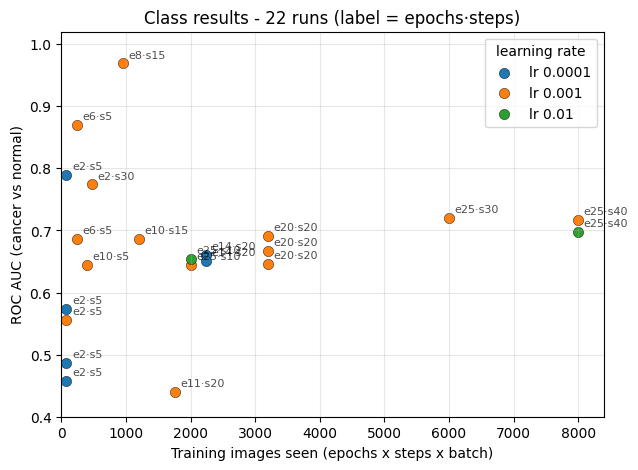

In [7]:
#@title 📊 Class results (sheet 4): AUC vs epochs
from google.colab import auth; auth.authenticate_user()
import gspread, numpy as np, pandas as pd, matplotlib.pyplot as plt
from google.auth import default
creds, _ = default(); gc = gspread.authorize(creds)
SHEET_URL = "https://docs.google.com/spreadsheets/d/1_-kntyt1fDtnypsKNcVb9zEVrtoevlwu3sPigNH5-hs/edit?usp=sharing"
sh = gc.open_by_url(SHEET_URL)
wss = sh.worksheets()
if len(wss) < 4:
    print("Sheet 4 does not exist yet - run the training cell (it creates and fills it).")
else:
    ws = wss[3]
    try:
        records = ws.get_all_records(value_render_option="UNFORMATTED_VALUE")
    except TypeError:
        records = ws.get_all_records()
    df = pd.DataFrame(records)
    need = {"train_images", "auc"}
    if df.empty:
        print("No data yet - train at least once.")
    elif not need.issubset(df.columns):
        print("Unexpected columns:", list(df.columns), "- clear tab 4 and re-log.")
    else:
        for c in ["epochs", "steps", "train_images", "head_depth", "head_neurons", "lr", "auc", "val_acc"]:
            if c in df.columns:
                df[c] = pd.to_numeric(df[c].astype(str).str.replace(",", ".", regex=False), errors="coerce")
        df = df.dropna(subset=["train_images", "auc"])
        plt.figure(figsize=(7, 5))
        if "lr" in df.columns and df["lr"].notna().any():
            for lr, g in df.groupby("lr"):
                g = g.sort_values("train_images")
                plt.scatter(g["train_images"], g["auc"], s=55, edgecolor="k", linewidth=.3, label="lr %g" % lr)
        else:
            plt.scatter(df["train_images"], df["auc"], s=55, edgecolor="k", linewidth=.3)
        for _, r in df.iterrows():
            tag = "e%d\u00b7s%d" % (int(r["epochs"]), int(r["steps"])) if {"epochs","steps"}.issubset(df.columns) else ""
            plt.annotate(tag, (r["train_images"], r["auc"]), textcoords="offset points", xytext=(4, 4), fontsize=8, alpha=.7)
        plt.xlabel("Training images seen (epochs x steps x batch)"); plt.ylabel("ROC AUC (cancer vs normal)")
        plt.ylim(0.4, 1.02); plt.xlim(left=0)
        plt.title("Class results - %d runs (label = epochs\u00b7steps)" % len(df))
        plt.legend(title="learning rate"); plt.grid(alpha=.3); plt.show()